In [1]:
# Install required library
!pip install sentence-transformers

In [2]:
# Import all required libraries
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# 10 sentences across 3 topics
# Topic 1: Cricket (4 sentences)
# Topic 2: Cooking (3 sentences)
# Topic 3: Cybersecurity (3 sentences)

sentences = [
    # Cricket
    "The batsman hit a magnificent six over long-on",
    "India won the test match by an innings and 50 runs",
    "The spinner took five wickets in the second innings",
    "The umpire raised his finger to signal the batsman was out LBW",

    # Cooking
    "Saute the onions in olive oil until they turn golden brown",
    "Add the spices and stir the curry on medium heat for ten minutes",
    "Let the dough rest for thirty minutes before rolling it out",

    # Cybersecurity
    "The hacker used a phishing email to steal login credentials",
    "Always use two-factor authentication to protect your accounts",
    "The firewall blocked the unauthorized access attempt successfully"
]

print(f"Total sentences: {len(sentences)}")
for i, s in enumerate(sentences):
    print(f"{i}: {s}")

Total sentences: 10
0: The batsman hit a magnificent six over long-on
1: India won the test match by an innings and 50 runs
2: The spinner took five wickets in the second innings
3: The umpire raised his finger to signal the batsman was out LBW
4: Saute the onions in olive oil until they turn golden brown
5: Add the spices and stir the curry on medium heat for ten minutes
6: Let the dough rest for thirty minutes before rolling it out
7: The hacker used a phishing email to steal login credentials
8: Always use two-factor authentication to protect your accounts
9: The firewall blocked the unauthorized access attempt successfully


In [4]:
# Load the AI model and generate embeddings
model = SentenceTransformer('all-MiniLM-L6-v2')

print("Generating embeddings...")
embeddings = model.encode(sentences)

print(f"Embedding shape: {embeddings.shape}")
print("Each sentence is now a vector of 384 numbers!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generating embeddings...
Embedding shape: (10, 384)
Each sentence is now a vector of 384 numbers!


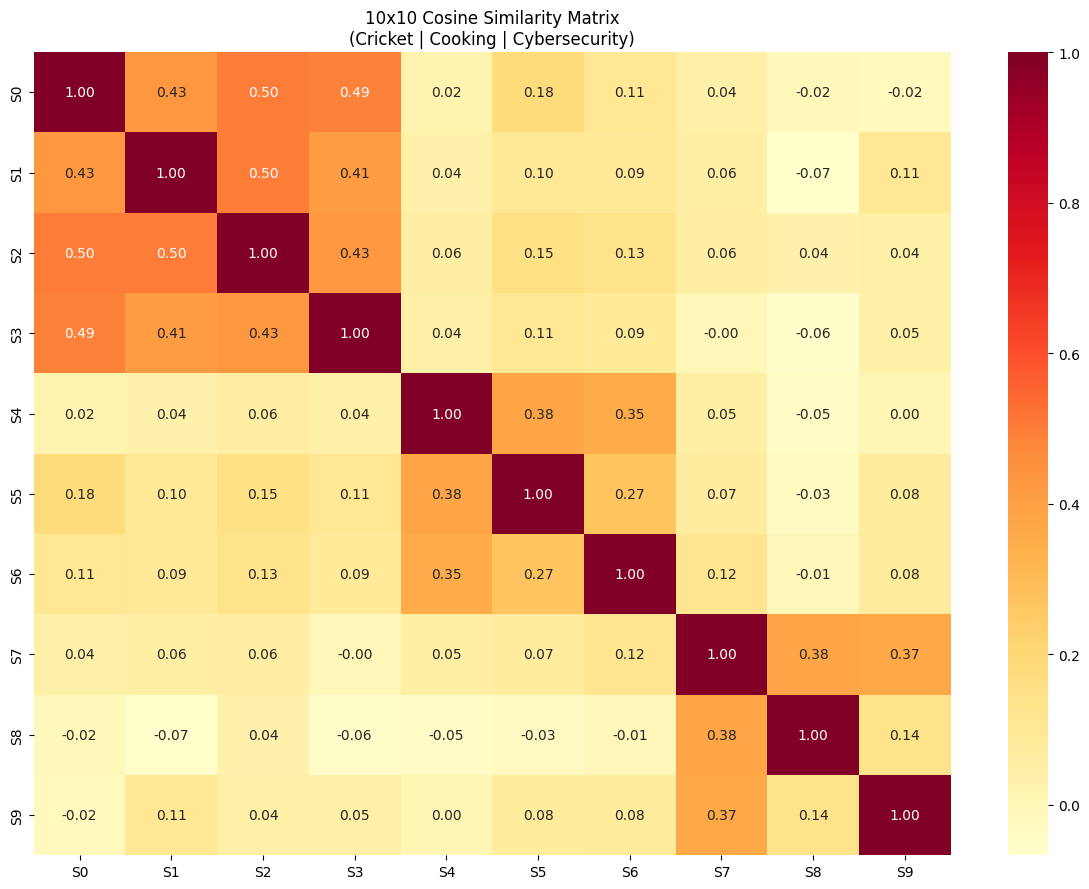

Heatmap saved!


In [5]:
# Compute 10x10 cosine similarity matrix
similarity_matrix = cosine_similarity(embeddings)

# Draw the heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(
    similarity_matrix,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    xticklabels=[f"S{i}" for i in range(10)],
    yticklabels=[f"S{i}" for i in range(10)]
)
plt.title("10x10 Cosine Similarity Matrix\n(Cricket | Cooking | Cybersecurity)")
plt.tight_layout()
plt.savefig("similarity_heatmap.png")
plt.show()
print("Heatmap saved!")

In [6]:
# Given query sentence
query = "The bowler took three wickets in one over"

# Generate embedding for the query
query_embedding = model.encode([query])

# Compute similarity with all 10 sentences
query_similarities = cosine_similarity(query_embedding, embeddings)[0]

# Sort and find top 2 matches
top_indices = np.argsort(query_similarities)[::-1][:2]

print(f"Query: '{query}'")
print()
print("Top 2 most similar sentences:")
print("-" * 50)
for rank, idx in enumerate(top_indices, 1):
    print(f"Rank {rank}: \"{sentences[idx]}\"")
    print(f"   Similarity Score: {query_similarities[idx]:.4f}")
    print()

Query: 'The bowler took three wickets in one over'

Top 2 most similar sentences:
--------------------------------------------------
Rank 1: "The spinner took five wickets in the second innings"
   Similarity Score: 0.6796

Rank 2: "The batsman hit a magnificent six over long-on"
   Similarity Score: 0.5580



In [7]:
import json
import os

notebook_path = None
# This ensures clean metadata when downloading
print("Notebook ready for export!")
print("All outputs saved successfully.")
print(f"Total sentences processed: {len(sentences)}")
print(f"Similarity matrix shape: {similarity_matrix.shape}")

Notebook ready for export!
All outputs saved successfully.
Total sentences processed: 10
Similarity matrix shape: (10, 10)
